# Baysian Inference IV
# Discrete Bayesian Networks

This article is part of a series:

- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20I%20-%20Bayesian%20Inference.ipynb">Bayesian Inference I - Bayesian Inference</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20II%20-%20Bayesian%20Linear%20Regression.ipynb">Bayesian Inference II - Bayesian Linear Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20III%20-%20Extending%20Bayesian%20Regression.ipynb">Bayesian Inference III - Extending Bayesian Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20IV%20-%20Bayesian%20Networks%20Discrete.ipynb">Bayesian Inference IV - Discrete Bayesian Networks</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20V%20-%20Bayesian%20Networks%20Continuous%20and%20Hybrid.ipynb">Bayesian Inference V - Continuous and Hybrid Bayesian Networks</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VI%20-%20BN%20Practical%20Applications.ipynb">Bayesian Inference VI - BN Practical Applications</a>

## Outline

<ul>
<li>What are Bayesian Networks?</li>
<ul>
    <li>Formal Definition</li>
</ul>

</br>
<li>Introducing <code>bnlearn</code></li>
</br>
<li>Creating a DAG</li>
</br>
<li>Setting Levels and Priors</li>
</br>
<li>Conditional Independence</li>
<ul>
    <li>V-Structures</li>
    <li>D-Separation</li>
    <li>Markov Blanket</li>
</ul>

</br>
<li>Conditional Independence Testing</li>
<ul>
    <li>The $G^2$ Measure</li>
    <li>Pearsons $X^2$ Measure</li>
    <li><code>arc.strength</code></li>
</ul>

</br>
<li>Fitting to Data</li>
</br>
<li>Network Scoring</li>
<ul>
    <li>Bayesian Information Criterion (BIC) Score</li>
    <li>Bayesian Dirichlet Equivalent (BDe) Score</li>
</ul>

</br>
<li>Exact Inference</li>
<ul>
    <li>Junction Trees</li>
</ul>

</br>
<li>Approximate Inference</li>
<ul>
<li><code>cpquery</code></li>
</ul>

## What Are Bayesian Networks?

Bayesian networks (BNs) are a class of graphical models that represent the probabilitic relationships among a set of variables as a set of nodes representing variables, and directed edges (called arcs) representing directions. The structure is called a directed acyclical graph (DAG) and this means that there are no loops or cycles. The directed edges lend well to causal interpretation of variable relationships, however they are also commonly used in non-causal situations of conditional independence among variables.

Judea Pearl, who has theorized and written much about the means by which to identify causal relationships from data, coined the term Bayesian network in his 1988 book "Probabilistic Reasoning in Intelligent Systems". Reasons for the word "Bayesian" include:
- The reliance on Bayes' theorem for conditioning as the basis for updating information.
- The subjective nature of choosing the variables' structure and directions.
- The ability to incorporate prior information.

<img src="https://github.com/pw598/Articles/blob/main/img/alarm_bn.png?raw=true" style="height: 400px; width:auto;">

### Formal Definition

Formally, Bayesian networks are the combination of:

1. A set of random variables $\mathbf{X} = \{X_1, \ldots, X_n\}$ describing the quantities of interest. The multivariate probability distribution of $\mathbf{X}$ is called the global distribution of the data, while the univariate distributions associated with each $X_i \in \mathbf{X}$ are called local distributions.

2. A directed acyclic graph (DAG) denoted $G = (\mathbf{V}, \mathbf{A})$, where each node $v \in \mathbf{V}$ is associated with one variable $X_i$, and the directed arcs $a \in \mathbf{A}$ that connect them represent probabilistic dependencies.

<u>Definition: Bayesian Network</u>

Consider random variables $X_1, \ldots, X_n$, a directed acyclic graph with $n$ numbered nodes, and suppose node $j$ at the graph is associated to the $X_j$ variable. The graph is a Bayesian network representing variables $X_1, \ldots, X_n$ if

- $P(X_1, \ldots, X_n) = \prod_{j=1}^n P(X_j|Parents(X_j))$,

where $Parents(X_j)$ denotes the set of all variables $X_i$ such that there is an arc from node $i$ to node $j$ in the graph.

Each node in a Bayesian network is associated with a probability distribution that quantifies the effect of the parent nodes on that node. The network encodes the joint probability distribution of all variables, allowing for efficient computation of conditional probabilities. Whereas naive Bayes would simplify the calculation by assuming independence of variables, BNs simplify the calculation by limiting the network of variable interaction.

-----
<i>"Consider the task of specifying an arbitrary joint distribution $P(x_1, \ldots, x_n)$ for $n$ dichotomous variables. To store $P(x_1, \ldots, x_n)$ explicitly would require a table with $2^n$ entries, an unthinkably large number by any standard. Substantial economy can be achieved when each variable depends on just a small subset of other variables. Such dependence information permits us to decompose large distribution functions into several small distributions - each involving a small subset of variables - and then to piece them together coherently to answer questions of a global nature."</i>
- Causality: Models, Reasoning and Inference (2000)
-----

The advantages of Bayesian networks include:
- The clear graphical structure.
- The ability to incorporate prior information.
- An interpretation that is natural for causal events.
- They provide good estimates when some predictors are missing.

-----
<i>"Compared to standard regression models in which the correlation between variables leads to multicollinearity and lack of robustness in model fitting, Bayesian networks leverage the mutual information between variables to define the conditional probability distributions".</i>
- Bayesian Networks: A Practical Guide to Applications (2008)
-----

<i>"Bayesian networks are almost the opposite of neural nets; they lend themselves to the introduction of intuition and deep understanding, whereas neural nets are nearly impossible to make sense of.</i>
- The Data Science Handbook (2018)
-----

There are generally three stages to building a BN:
1. Identification of important variables and their values.
2. Identification of predictor variables.
3. Parameterization of predictor and target variables.

Discretization may also take place, prior to step 3, as an alternative to dealing with the constraints of continuous variables. Gaussian Bayesian networks are convenient because of prior conjugacy, and the software for discrete and Gaussian networks is relatively user-friendly. The use of more customized distributions is possible, but requires approximate inference, which means utilizing samplers.

## Introducing <code>bnlearn</code>

<code>bnlearn</code> is a robust R package for Bayesian networks, managed by Marco Scutari. He has written extensively on the subject and provided a bounty of examples, code, and data. Although there is a Python version, the R version has been under development for over 10 years, and I believe that working with it will provide greater functionality and ease of use. I am using an .ipynb notebook, but within Google Colab with the runtime changed to use R instead of Python. Initial installations are slow on Google Colab, so you may prefer working with an R notebook within R Studio, or some other format/medium.

In [46]:
# install.packages("BiocManager")
# library("BiocManager")

# BiocManager::install("igraph")
# BiocManager::install("RcppEigen")
# BiocManager::install("RcppArmadillo")

# BiocManager::install("gRbase")
# BiocManager::install("gRain")
# BiocManager::install("bnlearn")
# BiocManager::install("Rgraphviz")

library("bnlearn")
library("Rgraphviz")
library("gRain")

## Creating a DAG

We will start simple with the canonical sprinkler example, involving 4 nodes:

- Cloudy (C): whether it is cloudy
- Rain (R): whether it is raining
- Sprinkler (S): whether the sprinkler is on
- Wet Grass (W): whether the grass is wet

We would expect all instances of the grass being wet to correspond to either rain or the sprinkler. We would probably also expect nearly all instances of rain to correspond to cloudy, and perhaps most instances of the sprinkler being on would correspond to not cloudy.

There are several ways to create a DAG. We'll start by simply generating nodes for the variables, and then subsequently connecting them:

In [47]:
dag <- empty.graph(nodes = c("C", "S", "R", "W"))
dag


  Random/Generated Bayesian network

  model:
   [C][S][R][W] 
  nodes:                                 4 
  arcs:                                  0 
    undirected arcs:                     0 
    directed arcs:                       0 
  average markov blanket size:           0.00 
  average neighbourhood size:            0.00 
  average branching factor:              0.00 

  generation algorithm:                  Empty 


As the word empty would suggest, we have nodes, but not yet connections; variables, but not yet levels or parameter values. We'll start by creating the arcs, and then plotting the DAG.

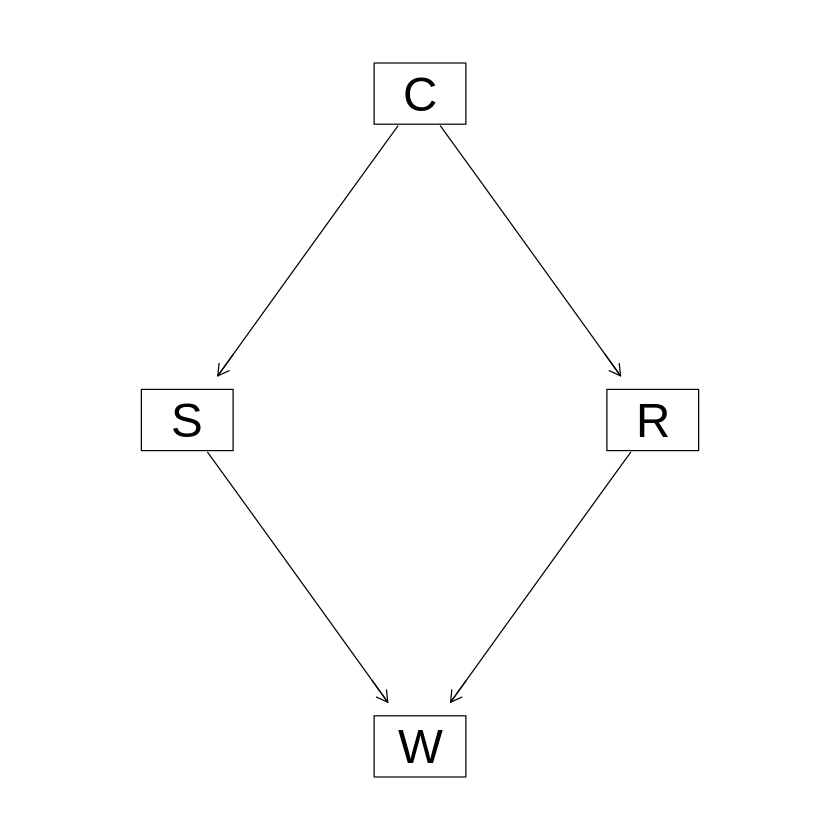

In [48]:
dag <- set.arc(dag, from="C", to="R")
dag <- set.arc(dag, from="C", to="S")
dag <- set.arc(dag, from="S", to="W")
dag <- set.arc(dag, from="R", to="W")

graphviz.plot(dag)

If at any time we want to retrieve the list of arcs, we can do so as follows:

In [49]:
arcs(dag)

from,to
C,R
C,S
S,W
R,W


When we inspect the <code>dag</code> object, we now see statistics on number of directed arcs, average neighborhood size, and average Markov blanket size, which refers to the network spanned by a node, its parents, and the parents of its children.

In [50]:
dag


  Random/Generated Bayesian network

  model:
   [C][S|C][R|C][W|S:R] 
  nodes:                                 4 
  arcs:                                  4 
    undirected arcs:                     0 
    directed arcs:                       4 
  average markov blanket size:           2.50 
  average neighbourhood size:            2.00 
  average branching factor:              1.00 

  generation algorithm:                  Empty 


This very manual specification of the DAG above is fine when there are only four variables, but when working with larger data, you may wish to compile your arcs dynamically into a matrix, and pass that into the setting function. This can be done with the following syntax.

In [51]:
dag2 <- empty.graph(nodes = c("C", "S", "R", "W"))
arc.set <- matrix(c("C", "S",
                    "C", "R",
                    "S", "W",
                    "R", "W"),
                  byrow=TRUE, ncol=2,
                  dimnames = list(NULL, c("from", "to")))
arcs(dag2) <- arc.set

We can use the <code>all.equal</code> function to confirm whether two DAGs are equal (this comes in handy with larger ones).

In [52]:
all.equal(dag, dag2)

[1] TRUE

An additional way to create a network is with the <code>model2network</code> function, which lists the nodes in a consecutive sequence of square brackets along with their dependencies. The syntax uses the | symbol to indicate a dependency (e.g. S|C means we're setting the S node and it is dependent upon C), and the colon to indicate "and".

In [53]:
dag3 <- model2network("[C][S|C][R|C][W|S:R]")

In [54]:
all.equal(dag, dag3)

[1] TRUE

## Setting Levels and Priors

Because the model is discrete (multinomial), the associations between nodes can be represented in their entirety by conditional probability tables, where each row and column intersection represents one possible event in the sample space.

To solve for the probability that the grass is wet, we could use the following formula:

\begin{align*}
&\phantom{{}={}}P(W=1)\\
&=\sum_{c=0}^1 \sum_{r=0}^1 \sum_{s=0}^1 P(W=1,C=c,R=r,S=s)\\
&= \sum_{c=0}^1 \sum_{r=0}^1 \sum_{s=0}^1 P(W=1 \mid S=s,R=r) \cdot P(S=s \mid C=c) \cdot P(R=r \mid C=c) \cdot P(C=c)\\
&= \sum_{c=0}^1 P(C=c) \sum_{r=0}^1 P(R=r \mid C=c) \sum_{s=0}^1 P(S=s \mid C=c) \cdot P(W=1 \mid S=s,R=r)
\end{align*}

Of course, <code>bnlearn</code> automates this for us. We have the option to learn levels and parameters from the data, but to set priors, we would start by setting up levels like the following.

In [55]:
C.lv <- c("True", "False")
S.lv <- c("True", "False")
R.lv <- c("True", "False")
W.lv <- c("True", "False")

In our case, it's rather simple, as each variable is a binary True or False. Next, we'll proceed to enter the probabilities specified in the conditional probability tables of the diagram above. Cloudy is the simplest to enter, as it does not depend on any other variables, and is either true or false with $50\%$ chance apiece.

In [56]:
C.prob <- array(c(0.5, 0.5), dim=2, dimnames = list(C=C.lv))
C.prob

C
 True False 
  0.5   0.5

The above required a two-element vector, whereas for Sprinkler, we will pass in a four-element array shaped $2 \times 2$. This is because there are four events in the sample space, corresponding to not just whether Sprinkler is true or false, but whether Cloudy is true or false as well.

In [57]:
S.prob <- array(c(0.1, 0.9, 0.5, 0.5), dim = c(2,2),
                dimnames = list(S = S.lv, C = C.lv))
S.prob

,True,False
True,0.1,0.5
False,0.9,0.5


Similarly, for Rain, the sample space has four elements, since we take into consideration whether or not it is cloudy as well.

In [58]:
R.prob <- array(c(0.8, 0.2, 0.2, 0.8), dim=c(2,2),
                dimnames = list(R = R.lv, C = C.lv))
R.prob

,True,False
True,0.8,0.2
False,0.2,0.8


Wet Grass is more complex, because it depends on both whether the sprinkler is on and whether it is raining. In addition to the two states that it may take, that makes for 8 permutations, represented in the conditional probability table in the diagram above, and in the list being passed to <code>W.prob</code> below.

In [59]:
W.prob <- array(c(0.99, 0.01, 0.9, 0.1, 0.9, 0.1, 0, 1), dim = c(2,2,2),
                dimnames = list(W = W.lv, S = S.lv, R = R.lv))

We use the <code>custom.fit</code> method to feed the lists of probabilities into the model.

In [60]:
cpt <- list(C = C.prob, S = S.prob, R = R.prob, W = W.prob)
fitted <- custom.fit(dag3,cpt)

The <code>nparams</code> property lets us see the number of permutations among connected variables and their levels.

In [61]:
nparams(fitted)

Warning message in nparams(fitted):
“the effective argument is deprecated and will be removed in 2025.”


[1] 9

We can inspect an individual element's conditional probabilities by targeting particular nodes of the <code>fitted</code> object such as follows.

In [62]:
fitted$W


  Parameters of node W (multinomial distribution)

Conditional probability table:
 
, , S = True

       R
W       True False
  True  0.99  0.90
  False 0.01  0.10

, , S = False

       R
W       True False
  True  0.90  0.00
  False 0.10  1.00


## Conditional Independence

The sets $X$ and $Y$ are said to be conditionally independent given $Z$ if $P(X|Y,Z) = P(X|Z)$. In words, learning about the value of $Y$ does not provide any additional information about $X$, once we know $Z$. Another way to say it is that $P(Y=y, Z=z) = P(X=x, Z=z)$.

### V-Structure

A v-structure (a.k.a. a collider) occurs when two parent nodes ($A$ and $B$) have directed edges pointing to a common child node $C$.

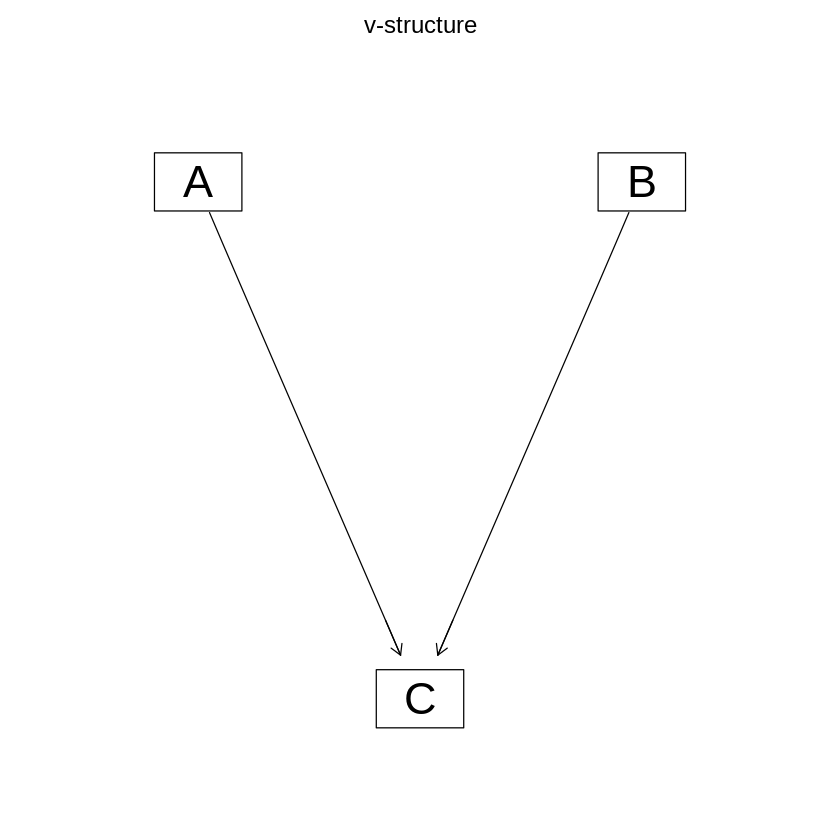

In [63]:
modelstr = '[A][B][C|B:A]'
vstruct = model2network(modelstr)
graphviz.plot(vstruct, main='v-structure')

### D-Separation

A d-structure, or d-separation structure, is a graphical condition that determines whether two sets of nodes $X$ and $Y$ are conditionally independent given a third set $Z$.

Two nodes $X$ and $Y$ are d-separated by a set of nodes $Z$ if every path between $X$ and $Y$ is blocked by $Z$. A path is 'blocked' if:

1. There exists a node $V$ on the path such that $V$ is in $Z$, and the edges on the path either converge to $V$ or point away from it.

2. There exists a node $V$ on the path such that neither $V$ nor any of its descendants are in $Z$, and the edges on the path converge to $V$ (i.e., $V$ is a v-structure or collider).

When $X$ and $Y$ are d-separated by $Z$, $X$ and $Y$ are conditionally independent given $Z$.

In [64]:
dag.nodes = nodes(dag)

for (n1 in dag.nodes[dag.nodes != "C"]) {
  for (n2 in dag.nodes[dag.nodes != "C"]) {
    if (n1 < n2) {
      if (dsep(dag, n1, n2, "C"))
        cat(n1, "and", n2, "are independent given C.\n")
    }
  }
}

R and S are independent given C.


Without conditioning on a third variable within the loop:

In [65]:
for (n1 in dag.nodes) {
  for (n2 in dag.nodes) {
    if (n1 < n2)
      if (dsep(dag, n1, n2))
      cat(n1, "and", n2, "are independent.\n")
  }
}

### Markov Blanket

A Markov blanket is the set of variables that renders a particular node conditionally independent of all other nodes in the network. The Markov blanket essentially 'shields' the node from the rest of the network, having computational implications. For a given node $X$ in a Bayesian network, the Markov blanket consists of 1) parents of $X$, 2) children of $X$, and 3) parents of the children of $X$.

If:
- $P_1$, $P_2$, are the parents of $X$,
- $C_1$, $C_2$, are the children of $X$, and
- $S_2$, $S_2$ are the parents of $C_1$ and $C_2$ respectively,

Then:
- The Markov blanket of $X$ is $\{P_1, P_2, C_1, C_2, S_1, S_2\}$

## Conditional Independence Testing

For variables that are not necessarily independent given the DAG structure, we speak in terms of the degree of conditional independence. We can test the null hypothesis that a variable is independent from another conditional on its parents using the $G^2$ metric (an adaptation of the log-likelihood ratio) or Pearsons $X^2$ as a test for conditional independence. Suppose we want to know the probability of Cloudy and Rainy being true, given the state of Sprinkler and Wet Grass. The $G^2$ measure is calculated as:

## The $G^2$ Measure

<h2>$
G^2(C,R|S,W) =
\sum_{c \in C} \sum_{r \in R} \sum_{S \in W}
\frac{n_{crk}}{n} ~log ~\frac{ n_{crk} n_{++k} }{ n_{c+k} n_{+rk} }
$</h2>

We denote the categories of Cloudy with $c \in C$, the categories of Rain with $r \in R$, and the configurations of Sprinkler and Wet Grass by $S \in W$. $n_{crk}$ is the number of observations for the combination of a category $c$ of Cloudy and a category $k$ of $S \times W$. The susbscript $+$ means the sum over an index. For example, $n_{c+k}$ is the number of observations for $c$ and $k$ obtained by summing over all categories of Rain.

The $G^2$ test, since equivalent to the mutual information test from information theory, is called upon by the <code>ci.test</code> function when <code>test = "mi"</code>.

Below we look up the mutual information of wet grass as a function of rain given the state of sprinkler plus cloudy, and as one might expect, a dependence is detected.

We must first generate some data, the four samples below.

In [66]:
C = c(TRUE, FALSE, FALSE, TRUE)
S = c(FALSE, TRUE, TRUE, FALSE)
R = c(TRUE, FALSE, FALSE, FALSE)
W = c(TRUE, TRUE, TRUE, FALSE)

df <- data.frame(C, S, R, W)
df$C = as.factor(df$C)
df$S = as.factor(df$S)
df$R = as.factor(df$R)
df$W = as.factor(df$W)

First we'll check the relationship (via mutual information or $G^2$) of rain to cloudiness.

In [67]:
ci.test("W", "C", test = "mi", data = df)


	Mutual Information (disc.)

data:  W ~ C  
mi = 1.7, df = 1, p-value = 0.2
alternative hypothesis: true value is greater than 0


Then wet grass to cloudiness given rain.

In [68]:
ci.test("W", "C", "R", test = "mi", data = df)


	Mutual Information (disc.)

data:  W ~ C | R
mi = 3.8, df = 2, p-value = 0.1
alternative hypothesis: true value is greater than 0


Or wet grass to cloudliness given both rain and the sprinkler.

In [69]:
ci.test("W", "C", c("R", "S"), test = "mi", data = df)


	Mutual Information (disc.)

data:  W ~ C | R + S
mi = 0, df = 4, p-value = 1
alternative hypothesis: true value is greater than 0


### Pearson's $X^2$ Measure

Pearsons $X^2$ is defined as follows:

<h2>$
X^2(C,R|S,W) =
\sum_{c \in C} \sum_{r \in R} \sum_{S \in W}
\frac{(n_{crk} - m_{crk})^2}{m_{cek}}
$</h2>

where

$m_{cek} = \frac{n_{c+k} n_{+rk}}{n_{++k}}$

The $X^2$ test is called upon by the <code>ci.test</code> function when <code>test = "x2"</code>.

In [70]:
ci.test("W", "R", "S", test = "x2", data = df)


	Pearson's X^2

data:  W ~ R | S
x2 = 2, df = 2, p-value = 0.4
alternative hypothesis: true value is greater than 0


In [71]:
ci.test("W", "R", c("S", "C"), test = "x2", data = df)


	Pearson's X^2

data:  W ~ R | S + C
x2 = 2, df = 4, p-value = 0.7
alternative hypothesis: true value is greater than 0


### <code><b>arc.strength</b></code>

We can use the <code>arc.strength</code> function to run conditional independence tests on each of the arcs present, and list their strength levels for comparison.

In [72]:
options(digits = 2)
arc.strength(dag, data = df, criterion = "x2")

,from,to,strength
,<chr>,<chr>,<dbl>
1,C,R,0.248
2,C,S,0.046
3,S,W,0.223
4,R,W,0.368


## Fitting to Data

As a reminder, we can use the <code>prop.table</code> function to view the empirical conditional probabilities.

In [73]:
prop.table(table(df[, c("C", "R")]), margin = 2)
prop.table(table(df[, c("R", "W")]), margin = 2)
prop.table(table(df[, c("S", "W")]), margin = 2)

       R
C       FALSE TRUE
  FALSE  0.67 0.00
  TRUE   0.33 1.00

       W
R       FALSE TRUE
  FALSE  1.00 0.67
  TRUE   0.00 0.33

       W
S       FALSE TRUE
  FALSE  1.00 0.33
  TRUE   0.00 0.67

The task of estimating parameters in the global distribution is simplified by the decomposition into local distributions. Common approaches include MLE and Bayesian estimation. Exact posterior densities make the interpretation more straight-forward, however Monte Carlo permutation tests and posterior estimates are also common.

We can invoke classic MLE upon the data with the <code>bn.fit</code> function, with <code>method = "mle"</code>.

In [74]:
bn.mle <- bn.fit(dag, data = df, method = "mle")
bn.mle


  Bayesian network parameters

  Parameters of node C (multinomial distribution)

Conditional probability table:
 FALSE  TRUE 
  0.5   0.5 

  Parameters of node S (multinomial distribution)

Conditional probability table:
 
       C
S       FALSE TRUE
  FALSE     0    1
  TRUE      1    0

  Parameters of node R (multinomial distribution)

Conditional probability table:
 
       C
R       FALSE TRUE
  FALSE   1.0  0.5
  TRUE    0.0  0.5

  Parameters of node W (multinomial distribution)

Conditional probability table:
 
, , R = FALSE

       S
W       FALSE TRUE
  FALSE     1    0
  TRUE      0    1

, , R = TRUE

       S
W       FALSE TRUE
  FALSE     0     
  TRUE      1     



We can instead get posterior distributions by setting <code>method = "bayes"</code>. The <code>iss</code> argument weights the prior distribution in the calculation of the posterior, with weight specified as the size of an imaginary sample. In the below, we'll assume our priors came from $20$ observations - or, that at least, that is the weight we would like them to have relative to our $4$ new observations.

In [75]:
bn.bayes <- bn.fit(dag, data = df, method = "bayes", iss=20)
bn.bayes


  Bayesian network parameters

  Parameters of node C (multinomial distribution)

Conditional probability table:
 FALSE  TRUE 
  0.5   0.5 

  Parameters of node S (multinomial distribution)

Conditional probability table:
 
       C
S       FALSE TRUE
  FALSE  0.42 0.58
  TRUE   0.58 0.42

  Parameters of node R (multinomial distribution)

Conditional probability table:
 
       C
R       FALSE TRUE
  FALSE  0.58 0.50
  TRUE   0.42 0.50

  Parameters of node W (multinomial distribution)

Conditional probability table:
 
, , R = FALSE

       S
W       FALSE TRUE
  FALSE  0.58 0.36
  TRUE   0.42 0.64

, , R = TRUE

       S
W       FALSE TRUE
  FALSE  0.42 0.50
  TRUE   0.58 0.50



## Network Scoring

### Bayesian Information Criterion (BIC)

The underlying structure of the DAG is often the object of investigation. The number of possible arcs grows exponentially with the number of variables, so learning the DAG can be a complex task (especially without some guidance).

Network scores allow us to compare the fit of different networks upon the data. One alternative is to use the Bayesian Information Criterion (BIC) as an approximation of the probability of the data given the graph. This penalizes for the number of parameters, and is defined as:

$$BIC(G, \mathcal{D}) = \sum_{i=1}^p \left[ log ~P(X_i | \prod_{X_i} - \frac{|\Theta|}{2} ~log ~n \right]$$

where $G$ is the DAG, $\mathcal{D}$ is the data, and $\Theta$ is the parameters of the global distribution.

The lower the score, the better. We can call upon the BIC using the <code>score</code> function with <code>type = "bic"</code>.

In [76]:
score(dag, data = df, type = "bic")

[1] -10

Let's add a new arc to the DAG, and see if that lowers the score.

In [77]:
dag4 <- set.arc(dag, from = "C", to = "W")
nparams(dag4, df)

Warning message in nparams(dag4, df):
“the effective argument is deprecated and will be removed in 2025.”


[1] 13

In [78]:
score(dag4, data = df, type = "bic")

[1] -13

Counter-intuitively, it suggests the model would be better if Cloudy is connected to Wet Grass directly, though intuitively, we know a more causal interpretation. Wet Grass is causally related to Rain, which is very likely to accompany Cloudy. Keep in mind we are using an extremely small sample of data to evaluate the fit.

### Bayesian Dirichlet Equivalent Uniform (BDe) Score

Structure learning can be done by finding the DAG $G$ that maximizes:

$P(G|\mathcal{D}) \propto P(G)P(\mathcal{D}|G) = P(G) \int P(D|G,\Theta) P(\Theta|G) d \Theta$

using Bayes theorem to decompose the posterior probability of the DAG $P(G|\mathcal{D})$ into the product of the prior distribution over all possible DAGs, $P(G)$, and the probability of the data, $P(\mathcal{D}|G)$. The latter requires estimating the parameters $\Theta$ of $G$; therefore, $\Theta$ has to be integrated out of the equation to make $P(G|\mathcal{D})$ independent of any specific choice of $\Theta$.

The prior distribution $P(G)$ provides a way to inject prior information available into the conditional independence associations between variables in $\mathbf{X}$. We may require that some arcs be present (or not present), and oriented in a certain direction.

The Bayesian Dirichlet equivalent uniform (BDeu, commonly shortened to BDe) can be used to estimate $P(\mathcal{D}|G)$. The BDe assumes a flat Dirichlet prior (the conjuate of the multinomial) over the space of the DAGs and the parameter space of each node. The only parameter of BDe is the imaginary sample size $\alpha$ associated with the Dirichlet prior, which determines how much weight is assigned to the prior as the size of sample supporting it. $BIC(G|\mathcal{D})$ approaches $log ~BDe(G|\mathcal{D})$ as $n \to \infty$.

$BDe(G|\mathcal{D}) = \prod_{i=1}^p BDe(X_i, \prod_{X_i})$

$BDe(G|\mathcal{D}) = \prod_{i=1}^p \prod_{j=1}^q \left\{ \frac{\Gamma(\alpha_{ij})}{ \Gamma(\alpha_{ij} + n_{ij}) } \prod_{k=1}^r \frac{ \Gamma(\alpha_{ij} + n_{ijk}) }{\Gamma(\alpha_{ijk})} \right\}$

- $p$ is the number of nodes in $G$
- $r_i$ is the number of categories for the node $X_i$
- $q_i$ is the number of configurations of the categories of the parents of $X_i$
- $n_{ijk}$ is the number of samples which have the $j^{th}$ category for node $X_i$ and the $k^{th}$ configuration for its parents

The BDe score can be obtained by setting <code>type = "bde"</code> with the <code>score</code> function. The imaginary sample size <code>iss</code> lets us determine the weight of the prior distribution.

In [79]:
score(dag, data = df, type = "bde", iss = 10)
score(dag, data = df, type = "bde", iss = 1)

[1] -11

[1] -11

We can use the hill-climbing algorithm to search for an optimal structure, as follows:

In [80]:
learned <- hc(df, score = "bde")
modelstring(learned)

[1] "[C][R][W][S|C]"

There is very little data, however, so the structure learned is not consistent with the known ground truth. There will be much more about structure learning in the next article in the series.

## Exact Inference

### Junction Trees

One of the best-known exact inference algorithms is a junction tree. A junction tree is a transformation of a 'moralised' graph of the network $\mathcal{B}$ in which the original nodes are clustered to reduce any network structure to a tree. 'Moralised' means marrying non-adjacent parent nodes which share a common child and changes the arcs from being directed to undirected.

The junction tree algorithm is as follows:
1. Moralise the BN.
2. Triangulate: break every cycle spanning $4$ or more nodes into subcycles of exactly $3$ nodes by adding arcs to the moral graph.
3. Identify the cliques $C_1, \ldots, C_k$ of the triangulated graph; i.e., maximal subsets of nodes in which each element is adjacent to all of the others.
4. Create a tree in which each clique is a node, and adjacent cliques are linked by arcs. If a node belongs to true cliques $C_i$ and $C_j$, it must also be included in all of the cliques in the unique path that connects $C_i$ and $C_j$.
5. Use the parameters of the local distributions to compute the parameter sets of the compound nodes of the junction tree.

Below, we'll use the gRain library to perform exact inference on our dicrete network.

In [40]:
library(gRain)
junction <- compile(as.grain(bn.bayes))

As an example, we can view the marginal probability of the grass being wet:

In [41]:
options(digits = 4)
querygrain(junction, nodes = "W")

$W
W
 FALSE   TRUE 
0.4637 0.5363

We can do it more explicitly with the <code>setEvidence</code> function.

In [42]:
jsprinkler <- setEvidence(junction, nodes = "W", states = "True")
querygrain(jsprinkler, nodes = "W")

$W
W
 FALSE   TRUE 
0.4637 0.5363

Or adjust the above to view the probability of rain given cloudiness.

In [43]:
jsprinkler <- setEvidence(junction, nodes = "C", states = "True")
querygrain(jsprinkler, nodes = "R")

$R
R
 FALSE   TRUE 
0.5417 0.4583

## Approximate Inference

Approximate inference algorithms use Monte Carlo simulations to sample from the global distribution of $\mathbf{X}$. They generate a large number of sample from the network $\mathcal{B}$ and estimate the condtional probabilities by considering the samples. While this approach is computationally expensive, it allows for complex specifications of the evidence and scales better to BNs including a large number of nodes.

-----
<i>"For discrete BNs, a simple way to implement approximate inference is to use rejection sampling. In rejection sampling, we generate random independent observations from the BN. Then we count how many match the evidence we are conditioning on and how many of those observations also match the event whose probability we are computing. The estimated conditional probability is the ratio between the latter and the former."</i>
- Bayesian Networks with Examples in R (2021)
-----

### <code><b>cpquery</b></code>

We can use the <code>cpquery</code> function of <code>bnlearn</code> to get the probability of an event (or joint event) occurring given some evidence, using approximate inference (sampling). This means that without a random seed, the results will change slightly each time.

As an example, we could query the probability that wet grass and rain are True given that cloudy is True.

In [44]:
cpquery(fitted, event = (W == "True") & (R == "True"),
          evidence = (C == "True"))

[1] 0.7114

We can use the <code>n</code> argument to specify the number of samples (also called particles) to generate.

In [45]:
cpquery(fitted, event = (W == "True") & (R == "True"),
          evidence = (C == "True"), n=10^6)

[1] 0.7278

We've covered a lot of ground regarding discrete networks, and it's true that for mathematical convenience, many people choose to discretize their continuous variables in order to work with multinomial distributions. But, alternatives exist, one of the most popular of which (also for mathematical convenience) is the Gaussian Bayesian Network, or GBN.

In the <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20V%20-%20Bayesian%20Networks%20Continuous%20and%20Hybrid.ipynb">next article</a>, we will take on more interesting data sets, and look at continuous and hybrid Bayesian networks, including structure learning and parameter learning.

## References

- Scutari, M., & Denis, J. B. (2014). Bayesian Networks With Examples in R (1st ed.). CRC Press. https://www.bnlearn.com/book-crc-2ed/

- Pearl, J. (2000). Causality: Models, Reasoning, and Inference. Cambridge University Press.

- Pourret, O., Naim, P., & Marcot, B. (2008). Bayesian Networks: A Practical Guide to Applications (1st ed.). Wiley. https://www.wiley.com/en-ca/Bayesian+Networks%3A+A+Practical+Guide+to+Applications-p-9780470994542

- Martin, O. (2024). Bayesian Analysis with Python (3rd ed.). Packt. https://www.packtpub.com/en-ca/product/bayesian-analysis-with-python-9781836644835

- Bellot, D. (2016). Learning Probabilistic Graphical Models in R (1st ed.). Packt. https://www.packtpub.com/en-ca/product/learning-probabilistic-graphical-models-in-r-9781784392055

- Murphy, K. (n.d.). A Brief Introduction to Graphical Models and Bayesian Networks. University of British Columbia. https://www.cs.ubc.ca/~murphyk/Bayes/bnintro.html

- (The Sprinkler Example). StackExchange. https://math.stackexchange.com/questions/1086047/bayesian-network-sprinkler-example

- Cady, F. (2018). The Data Science Handbook II (2nd ed.). Wiley.